# OCR engines — EasyOCR, RapidOCR (Paddle), Tesseract

Este notebook **não treina** um reconhecedor. Os três motores já vêm pré-treinados. O que ele faz é **compará-los** no dataset `data/ocr/`, em que cada caixa OBB tem como *classe* o **texto impresso** (não `name` / `number` / `colection`).

| Passo | Objetivo |
|---|---|
| 0 | Caminhos e recorte das caixas anotadas |
| 1 | Ambiente |
| 2 | Inventário do dataset (classe = ground truth) |
| 3 | Métricas — o que cada uma mede e por que entra no ranking |
| 4 | Carregar os 3 motores (`src/ocr` + RapidOCR + Tesseract) |
| 5 | Rodar OCR em cada caixa e ranquear |
| 6 | Erros e amostras visuais |

O detector de ROI **não entra** nesta avaliação: a caixa já está no label. Assim o ranking mede leitura, não detecção.

Código de recorte / limpeza: `src/ocr/read_card.py`. Tabelas: `src/ocr/runs/` (gitignored).


Altere `MAX_BOXES` se quiser um smoke test (por exemplo `40`). `None` processa o split inteiro.

O zip atual do Roboflow só traz `test/` — train/valid vazios não impedem a comparação.


In [1]:
from __future__ import annotations

import asyncio
import sys
from pathlib import Path

if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

VERSION = "v1"
EXPERIMENT_NAME = f"ocr-cmp-{VERSION}"
MAX_BOXES = None  # None = split inteiro (~699 caixas; alguns minutos)
EVAL_SPLIT = "test"
MAX_SHOW = 8


def find_repo() -> Path:
    here = Path(".").resolve()
    for folder in [here, *here.parents]:
        if (folder / "src" / "cropper" / "rectify.py").is_file() and (folder / "src" / "detection").is_dir():
            return folder
    raise FileNotFoundError(
        "Abra o notebook no repositorio PTCG Scanner (pastas src/cropper/ e src/detection/)."
    )


REPO = find_repo()
OCR_ROOT = REPO / "src" / "ocr"
DATASET_DIR = REPO / "data" / "ocr"
DATA_YAML = DATASET_DIR / "data.yaml"
OCR_RUNS = OCR_ROOT / "runs"

print("Python      :", sys.executable)
print("Experimento :", EXPERIMENT_NAME)
print("Dataset     :", DATASET_DIR, " yaml=", DATA_YAML.exists(), sep="")
print("Saida       :", OCR_RUNS)
print("Split       :", EVAL_SPLIT, " | MAX_BOXES=", MAX_BOXES, sep="")
print("Este notebook nao treina YOLO. As caixas vem dos labels em data/ocr.")
exe = sys.executable.replace("\\", "/").lower()
if ".venv" not in exe:
    print("AVISO: o kernel nao parece ser a .venv do projeto.")
    print("No Cursor: Select Kernel -> Python (.venv)")


Python      : c:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\.venv\Scripts\python.exe
Experimento : ocr-cmp-v1
Dataset     :C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\ocr yaml=True
Saida       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\ocr\runs
Split       :test | MAX_BOXES=None
Este notebook nao treina YOLO. As caixas vem dos labels em data/ocr.


C:\Users\Pichau\AppData\Local\Temp\ipykernel_26324\1505452072.py:8: DeprecationWarning: 'asyncio.WindowsSelectorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
C:\Users\Pichau\AppData\Local\Temp\ipykernel_26324\1505452072.py:8: DeprecationWarning: 'asyncio.set_event_loop_policy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())


## 1. Environment


In [2]:
import subprocess
import sys

print("Kernel:", sys.executable)

CORE = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "pyyaml": "yaml",
    "easyocr": "easyocr",
}
OPTIONAL = {
    "rapidocr": "rapidocr",
    "pytesseract": "pytesseract",
}

missing = []
for pip_name, module_name in CORE.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Instalando pacotes obrigatorios (pode demorar):", missing, flush=True)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Dependencias centrais ok.")

for pip_name, module_name in OPTIONAL.items():
    try:
        __import__(module_name)
        print(pip_name, "ok")
    except ImportError:
        print("Instalando opcional", pip_name, "...", flush=True)
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        except subprocess.CalledProcessError as exc:
            print("Falha ao instalar", pip_name, "- esse motor sera pulado.", exc)


Kernel: c:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\.venv\Scripts\python.exe
Dependencias centrais ok.
rapidocr ok
pytesseract ok


In [3]:
from datetime import datetime
import platform

import pandas as pd
import torch

rows = [
    {"Item": "Data/hora", "Valor": datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    {"Item": "SO", "Valor": platform.platform()},
    {"Item": "Python", "Valor": platform.python_version()},
    {"Item": "PyTorch", "Valor": torch.__version__},
    {"Item": "CUDA", "Valor": torch.cuda.is_available()},
    {"Item": "GPU", "Valor": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "-"},
]
print(pd.DataFrame(rows).to_string(index=False))

     Item                     Valor
Data/hora       2026-10-01 16:49:41
       SO Windows-11-10.0.26200-SP0
   Python                    3.14.7
  PyTorch              2.11.0+cu128
     CUDA                      True
      GPU   NVIDIA GeForce RTX 5060


## 2. Dataset: a classe **é** o texto

No `data.yaml` cada `names[id]` é a transcrição da faixa (ex.: `Scatterbug`, `005-66`, `TEF`, `--`). O label YOLO OBB traz `class_id` + 8 coordenadas.

Isso **não** é um problema de classificação fechada com 3 tipos. São centenas de strings distintas. Por isso **não** usamos mAP / matriz de confusão de detector: a “classe” não é um tipo semântico, é o próprio ground truth da leitura.

O tipo de faixa (`name` / `number` / `collection`) é **inferido da string** só para escolher allowlist e o normalizador — o mesmo espírito do pipeline em `src/ocr`. Caixas cujo GT é só traço (`--`, `-----ex`, …) entram como **ilegível**: o anotador não tinha texto lícito; elas **não** entram no ranking.


In [4]:
import re
import sys
from collections import Counter

import cv2
import numpy as np
import yaml

sys.path.insert(0, str(OCR_ROOT))

from read_card import warp_quad, _WARP_PAD  # noqa: E402

_NUM_RE = re.compile(r"^(?:[A-Z]{1,8})?\d{1,4}[-/](?:[A-Z]{1,8})?\d{1,4}$", re.I)
_ILLEGIBLE_RE = re.compile(r"^[-_.\s]*(?:v|ex|gx|vstar|vmax)?[-_.\s]*$", re.I)


def load_class_names(path: Path) -> dict[int, str]:
    data = yaml.safe_load(path.read_text(encoding="utf-8"))
    names = data["names"]
    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}
    return {i: str(name) for i, name in enumerate(names)}


def infer_tipo(gt: str) -> str:
    """Heurística só para allowlist/normalizador — o GT continua sendo a string da classe."""
    s = (gt or "").strip()
    if not s:
        return "vazio"
    compact = re.sub(r"[^A-Za-z0-9]", "", s)
    if _ILLEGIBLE_RE.fullmatch(s):
        return "ilegivel"
    if not re.search(r"\d", s) and s.count("-") >= 2 and len(compact) <= 6:
        return "ilegivel"
    token = re.sub(r"\s+", "", s)
    if _NUM_RE.fullmatch(token):
        return "number"
    if re.fullmatch(r"\d{2,4}", compact) and "-" not in s and "/" not in s:
        return "collection"
    if re.fullmatch(r"S\d{1,2}[A-Za-z]{0,2}", compact, re.I):
        return "collection"
    if " " not in s and 2 <= len(compact) <= 7 and s.isupper() and re.search(r"[A-Za-z]", compact):
        return "collection"
    if " " not in s and 2 <= len(compact) <= 5 and re.fullmatch(r"[A-Z]{2,5}\d{0,2}[A-Za-z]{0,2}", compact):
        return "collection"
    return "name"


def split_counts(split: str) -> dict[str, int]:
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"
    images = list(img_dir.glob("*.*")) if img_dir.is_dir() else []
    labels = list(lab_dir.glob("*.txt")) if lab_dir.is_dir() else []
    boxes = 0
    for path in labels:
        boxes += sum(1 for line in path.read_text(encoding="utf-8").splitlines() if line.strip())
    return {"imagens": len(images), "labels": len(labels), "caixas": boxes}


if not DATA_YAML.is_file():
    raise FileNotFoundError(f"Unzip the Roboflow OCR dataset into {DATASET_DIR}")

CLASS_NAMES = load_class_names(DATA_YAML)
tipo_classes = Counter(infer_tipo(name) for name in CLASS_NAMES.values())
print(f"Classes no yaml : {len(CLASS_NAMES)}")
print(pd.DataFrame(
    [{"tipo inferido": k, "classes": v} for k, v in sorted(tipo_classes.items())]
).to_string(index=False))
print()
print(pd.DataFrame(
    [{"split": split, **split_counts(split)} for split in ("train", "valid", "test")]
).to_string(index=False))

Classes no yaml : 517
tipo inferido  classes
   collection       42
     ilegivel       12
         name      212
       number      251

split  imagens  labels  caixas
train        0       0       0
valid        0       0       0
 test      274     274     699


## 3. Métricas (ler **antes** de rodar)

O alvo é: *qual motor lê melhor o texto da faixa, dado o recorte certo?* Não medimos localização. Cada caixa anotada vira um exemplo `(imagem_recortada, texto_gt)`.

### O que **não** entra

| Métrica de detector | Por que não |
|---|---|
| mAP / Precision / Recall de classe | Há ~500 “classes” que na verdade são transcrições. Um nome que aparece uma vez não forma uma classe de detecção. |
| Matriz de confusão N×N | Confundiria `Pikachu` com `Pikachu V` como se fossem categorias, não erros de string. |
| IoU da caixa | A caixa já é ground truth. Erro de caixa seria outro experimento (`train_roi.ipynb`). |

### Normalização (fold)

OCR devolve caixa, acento e `005-66` vs `5/66`. O pipeline também não exige igualdade literal. Antes de marcar acerto:

- **nome** — minúsculas, sem acento, sem pontuação (`Pikachu` = `pikachu`).
- **número** — hífen vira barra; zeros à esquerda caem (`005-66` = `5/66`). Prefixo tipo `GG34/GG70` permanece.
- **coleção** — só alfanumérico em maiúsculas; as 3 primeiras letras podem errar **1** caractere (`TEF` vs `TFF`), porque o catálogo ainda casa o set.

Acerto **bruto** (case-sensitive) fica só como diagnóstico: é rígido demais para escolher motor.

### Métricas que entram no ranking

**1. Acerto normalizado (`exact_norm`)** — fração das caixas *legíveis* em que `fold(gt) == fold(pred)` (número) ou a regra da coleção. É a métrica **principal**: responde “o pipeline conseguiria usar essa leitura?”.

Dois números lado a lado:

- `exact_raw` — fold no texto cru do motor (compara motores de igual para igual).
- `exact_clean` — depois do `_clean` de `read_card.py` (allowlist + `O→0` etc.). É o que o produto veria.

O ranking oficial usa **`exact_clean`**, com desempate em CER.

**2. CER (character error rate)** — distância de Levenshtein entre as strings já *foldadas*, dividida pelo tamanho do GT. `0` = idêntico; `1` ≈ reescreveu tudo. Serve quando o acerto binário empata ou quando o motor “quase acerta” (`Pikachu` vs `Pikchu`).

Não usamos CER no texto cru com caixa/acento: isso puniria um motor só por estilo, não por conteúdo.

**3. WER (só em `name`)** — mesma ideia no nível da palavra (`Zacian V`). Números e códigos de set são um token só; WER ali não acrescenta nada.

**4. Acerto por tipo** — nome, número e coleção não são igualmente difíceis. Tesseract costuma ruir em nome e sobreviver em dígitos; Paddle às vezes ganha no nome. Uma média única esconderia isso. O ranking global continua micro (por caixa); a tabela por tipo explica *onde* o vencedor ganhou.

**5. Taxa de vazio** — GT legível e predito `""`. Motor que “cala” não é melhor do que um que alucina, mas o modo de falha muda o match no catálogo (vazio não casa; lixo pode casar errado).

**6. Latência (ms/caixa)** — critério de desempate operacional, não de qualidade. Só vale depois de `exact_clean` e CER.

### Caixas ilegíveis (`--`, `-----ex`, …)

O GT diz que o texto **não** era lível. Elas saem do ranking. Relatamos à parte a taxa de predito vazio: um motor honesto deveria calar; um que inventa `eevee` nessas faixas é pior para o catálogo.

### Como se escolhe o vencedor

1. Maior **`exact_clean`** no subconjunto legível (micro, todas as caixas).
2. Em empate (diferença < 1 ponto percentual), menor **CER médio** no mesmo subconjunto.
3. Se ainda empatar, menor ms/caixa.

Não ranqueamos por WER nem por acerto bruto. Também não ranqueamos só no tipo mais fácil (número).


## 4. Load the three engines


In [5]:
import shutil
import time
import unicodedata

from read_card import (
    _FIELD_ALLOW,
    _NUMBER_TRANSLATE,
    _clean,
    _parse_ocr_items,
    _readtext,
    _strip_variants,
    enhance_strip,
)

ENGINES = ("easyocr", "paddleocr", "tesseract")
LABEL = {"easyocr": "EasyOCR", "paddleocr": "RapidOCR (Paddle)", "tesseract": "Tesseract"}
loaded = {}

reader = None
paddle = None
tesseract_cmd = None

print("Carregando EasyOCR (en+pt). A 1a vez baixa pesos e pode levar 1-2 min ...", flush=True)
import easyocr
import pandas as pd
import torch

reader = easyocr.Reader(["en", "pt"], gpu=torch.cuda.is_available())
loaded["easyocr"] = "ok"
print("EasyOCR ok | gpu=", torch.cuda.is_available(), flush=True)

try:
    from rapidocr import RapidOCR

    paddle = RapidOCR(params={"Global.log_level": "error"})
    loaded["paddleocr"] = "ok"
    print("RapidOCR ok", flush=True)
except Exception as exc:
    loaded["paddleocr"] = f"skip: {exc}"
    print("RapidOCR skip:", exc, flush=True)

tesseract_cmd = shutil.which("tesseract")
if not tesseract_cmd:
    for candidate in (
        Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe"),
        Path(r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe"),
    ):
        if candidate.is_file():
            tesseract_cmd = str(candidate)
            break
if tesseract_cmd:
    import pytesseract

    pytesseract.pytesseract.tesseract_cmd = str(tesseract_cmd)
    loaded["tesseract"] = f"ok ({tesseract_cmd})"
    print("Tesseract ok")
else:
    loaded["tesseract"] = "skip: binario tesseract nao encontrado"
    print(loaded["tesseract"])

print(pd.DataFrame([{"motor": LABEL[k], "status": loaded.get(k, "skip")} for k in ENGINES]).to_string(index=False))
ACTIVE = [k for k in ENGINES if str(loaded.get(k, "")).startswith("ok")]
if not ACTIVE:
    raise RuntimeError("Nenhum motor de OCR carregou. Rode a celula de ambiente no kernel .venv.")
print("Ativos:", ", ".join(LABEL[k] for k in ACTIVE))


Carregando EasyOCR (en+pt). A 1a vez baixa pesos e pode levar 1-2 min ...
EasyOCR ok | gpu= True
RapidOCR ok
Tesseract ok
            motor                                            status
          EasyOCR                                                ok
RapidOCR (Paddle)                                                ok
        Tesseract ok (C:\Program Files\Tesseract-OCR\tesseract.exe)
Ativos: EasyOCR, RapidOCR (Paddle), Tesseract


## 5. Run OCR on labeled boxes

Cada linha de label vira um recorte (`warp_quad`) e os motores ativos leem a mesma imagem já realçada (`enhance_strip`). O tipo inferido só muda allowlist / whitelist / `_clean`.


In [6]:
needed = ("REPO", "CLASS_NAMES", "ACTIVE", "EVAL_SPLIT", "OCR_RUNS")
missing_state = [name for name in needed if name not in globals()]
if missing_state:
    raise RuntimeError("Execute as celulas anteriores primeiro. Falta: " + ", ".join(missing_state))

def fold_name(text: str) -> str:
    text = unicodedata.normalize("NFKD", text or "")
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^0-9A-Za-z]+", "", text).casefold()


def fold_collection(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "", text or "").upper()[:3]


def fold_number(text: str) -> str:
    raw = (text or "").upper().replace(" ", "").replace("\\", "/").replace("⁄", "/").replace("-", "/")
    prefixed = re.search(r"([A-Z]{2,})(\d{1,4})/([A-Z]{2,})(\d{1,4})", raw)
    if prefixed:
        left, a, right, b = prefixed.groups()
        return f"{left}{int(a)}/{right}{int(b)}"
    translated = raw.translate(_NUMBER_TRANSLATE)
    plain = re.search(r"(\d{1,4})/(\d{1,4})", translated)
    if plain:
        return f"{int(plain.group(1))}/{int(plain.group(2))}"
    if "/" not in translated:
        digits = re.sub(r"\D", "", translated)
        letters = re.sub(r"[^A-Z]", "", translated)
        if digits and not letters:
            return str(int(digits))
    return re.sub(r"[^A-Z0-9/]", "", translated)


def fold_for(tipo: str, text: str) -> str:
    if tipo == "number":
        return fold_number(text)
    if tipo == "collection":
        return fold_collection(text)
    return fold_name(text)


def edit_distance(left, right) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)
    prev = list(range(len(right) + 1))
    for i, ca in enumerate(left, start=1):
        curr = [i]
        for j, cb in enumerate(right, start=1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]


def cer(gt: str, pred: str) -> float:
    if not gt and not pred:
        return 0.0
    return edit_distance(gt, pred) / max(len(gt), 1)


def same_collection(expected: str, predicted: str) -> bool:
    left = fold_collection(expected)
    right = fold_collection(predicted)
    if not left and not right:
        return True
    if not left or not right:
        return False
    return edit_distance(left, right) <= 1


def same_field(tipo: str, expected: str, predicted: str) -> bool:
    if tipo == "number":
        return fold_number(expected) == fold_number(predicted)
    if tipo == "collection":
        return same_collection(expected, predicted)
    return fold_name(expected) == fold_name(predicted)


def word_tokens(text: str) -> list[str]:
    text = unicodedata.normalize("NFKD", text or "")
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return [tok.casefold() for tok in re.findall(r"[0-9A-Za-z]+", text)]


def wer(gt: str, pred: str) -> float:
    left, right = word_tokens(gt), word_tokens(pred)
    if not left and not right:
        return 0.0
    return edit_distance(left, right) / max(len(left), 1)


def _easy_raw(image: np.ndarray, field: str) -> str:
    min_h = 80 if field == "collection" else 112
    enhanced = enhance_strip(image, min_h=min_h)
    allow = _FIELD_ALLOW[field]

    def _run(view: np.ndarray) -> tuple[str, float]:
        rgb = cv2.cvtColor(view, cv2.COLOR_GRAY2RGB)
        return _parse_ocr_items(_readtext(reader, rgb, allow))

    text, conf = _run(enhanced)
    if text.strip():
        return text
    if field == "name":
        text, _conf = _run(255 - enhanced)
        return text
    if field == "number":
        best_text, best_conf = "", -1.0
        for view in _strip_variants(enhanced)[1:]:
            cand, cand_conf = _run(view)
            if cand.strip() and cand_conf > best_conf:
                best_text, best_conf = cand, cand_conf
        return best_text
    return text


def _paddle_raw(image: np.ndarray, field: str) -> str:
    min_h = 80 if field == "collection" else 112
    gray = enhance_strip(image, min_h=min_h)
    view = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if gray.ndim == 2 else gray
    try:
        result = paddle(view, use_det=False, use_cls=False)
    except TypeError:
        result = paddle(view)
    texts = [str(item).strip() for item in (getattr(result, "txts", None) or []) if str(item).strip()]
    if texts:
        return " ".join(texts)
    if isinstance(result, (list, tuple)):
        parts = []
        blob = result[0] if result and isinstance(result[0], list) else result
        for item in blob or []:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                payload = item[1]
                if isinstance(payload, (list, tuple)):
                    parts.append(str(payload[0]).strip())
                else:
                    parts.append(str(payload).strip())
        return " ".join(p for p in parts if p)
    return ""


def _tesseract_raw(image: np.ndarray, field: str) -> str:
    import pytesseract

    view = enhance_strip(image, min_h=80 if field == "collection" else 112)
    config = "--psm 7"
    if field == "number":
        config += " -c tessedit_char_whitelist=0123456789/OoQqDdIiLlZzSsGgBb"
    elif field == "collection":
        config += " -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789"
    data = pytesseract.image_to_data(view, lang="eng", config=config, output_type=pytesseract.Output.DICT)
    words = [str(word).strip() for word in data.get("text", []) if str(word).strip()]
    return " ".join(words)


READERS = {
    "easyocr": _easy_raw,
    "paddleocr": _paddle_raw,
    "tesseract": _tesseract_raw,
}


def iter_boxes(split: str):
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"
    if not img_dir.is_dir() or not lab_dir.is_dir():
        return
    images = {path.stem: path for path in img_dir.iterdir() if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}}
    for lab_path in sorted(lab_dir.glob("*.txt")):
        img_path = images.get(lab_path.stem)
        if img_path is None:
            continue
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue
        h, w = bgr.shape[:2]
        for box_i, line in enumerate(lab_path.read_text(encoding="utf-8").splitlines()):
            parts = line.split()
            if len(parts) < 9:
                continue
            cls_id = int(float(parts[0]))
            gt = CLASS_NAMES.get(cls_id)
            if gt is None:
                continue
            pts = np.array(list(map(float, parts[1:9])), dtype=np.float32).reshape(4, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
            yield {
                "image": img_path.name,
                "path": img_path,
                "box_i": box_i,
                "gt": gt,
                "tipo": infer_tipo(gt),
                "quad": pts,
                "bgr": bgr,
            }


rows = []
n_seen = 0
t0 = time.perf_counter()
for sample in iter_boxes(EVAL_SPLIT):
    if MAX_BOXES is not None and n_seen >= int(MAX_BOXES):
        break
    n_seen += 1
    tipo = sample["tipo"]
    field = tipo if tipo in {"name", "number", "collection"} else "name"
    crop = warp_quad(sample["bgr"], sample["quad"], pad=_WARP_PAD.get(field, 0.12))
    row = {
        "imagem": sample["image"],
        "caixa": sample["box_i"],
        "tipo": tipo,
        "gt": sample["gt"],
        "legivel": tipo not in {"ilegivel", "vazio"},
    }
    if n_seen == 1 or n_seen % 10 == 0:
        elapsed = time.perf_counter() - t0
        eta = (elapsed / n_seen) * max((MAX_BOXES or 699) - n_seen, 0)
        print(
            f"[{n_seen}] {sample['image'][:40]} gt={sample['gt']!r} tipo={tipo} {elapsed:.0f}s eta~{eta:.0f}s",
            flush=True,
        )
    for engine in ACTIVE:
        started = time.perf_counter()
        try:
            raw = READERS[engine](crop, field) if crop.size else ""
        except Exception as exc:
            raw = ""
            row[f"err_{engine}"] = str(exc)
        elapsed = 1000.0 * (time.perf_counter() - started)
        cleaned = _clean(field, raw) if row["legivel"] else (raw or "")
        row[f"raw_{engine}"] = raw
        row[f"clean_{engine}"] = cleaned
        row[f"ms_{engine}"] = round(elapsed, 1)
        row[f"ok_raw_{engine}"] = same_field(field, sample["gt"], raw) if row["legivel"] else False
        row[f"ok_clean_{engine}"] = same_field(field, sample["gt"], cleaned) if row["legivel"] else False
        row[f"cer_raw_{engine}"] = cer(fold_for(field, sample["gt"]), fold_for(field, raw)) if row["legivel"] else np.nan
        row[f"cer_clean_{engine}"] = cer(fold_for(field, sample["gt"]), fold_for(field, cleaned)) if row["legivel"] else np.nan
        if field == "name" and row["legivel"]:
            row[f"wer_{engine}"] = wer(sample["gt"], cleaned)
        else:
            row[f"wer_{engine}"] = np.nan
    rows.append(row)

detail = pd.DataFrame(rows)
OCR_RUNS.mkdir(parents=True, exist_ok=True)
detail_path = OCR_RUNS / f"{EXPERIMENT_NAME}_boxes.csv"
detail.to_csv(detail_path, index=False, encoding="utf-8")
print(f"\nCaixas lidas : {len(detail)}  em {time.perf_counter() - t0:.1f}s")
print(f"Legiveis     : {int(detail['legivel'].sum())}  |  ilegiveis: {int((~detail['legivel']).sum())}")
print(f"CSV          : {detail_path}")
print(detail["tipo"].value_counts().rename_axis("tipo").reset_index(name="n").to_string(index=False))

[1] 0079-1_jpg.rf.9f78d808f116a820c23f4028e6 gt='BLK' tipo=collection 0s eta~10s
[10] 0118-1_jpg.rf.ebce68247af9bd1c0bf2654495 gt='ASC' tipo=collection 2s eta~120s
[20] 0137-1_jpg.rf.b3773fa70defc6763fb2303773 gt='Archeops' tipo=name 3s eta~112s
[30] 0227-1_jpg.rf.a606acd8a40f1d8e189584e2ed gt='BLK' tipo=collection 5s eta~108s
[40] 0272-1_jpg.rf.e8ca29f29952d7b4b5117d0787 gt='181-159' tipo=number 6s eta~105s
[50] 0331-1_jpg.rf.5ececba46524258f92f042bf44 gt='Liepard' tipo=name 8s eta~102s
[60] 1005-3_jpg.rf.15e02f237a9300986b2d51986c gt='PFL' tipo=collection 9s eta~101s
[70] 1009-3_jpg.rf.78d98b0bd8509334b9b9240341 gt='Giratina' tipo=name 11s eta~99s
[80] 1013-1_jpg.rf.48ab736bb618adc3e021ae8829 gt='Zacian V' tipo=name 13s eta~97s
[90] 1017-3_jpg.rf.0a192afd77c2598fe0289d61a6 gt='Arctibax' tipo=name 14s eta~95s
[100] 1021-1_jpg.rf.64b3cab419cf74bf730fdda8a1 gt='Weavile' tipo=name 16s eta~93s
[110] 1025-1_jpg.rf.6a5708dc6731fd5f54ed1f87cd gt='41-214' tipo=number 17s eta~92s
[120] 1029-1_

## 6. Ranking

Vencedor = maior `exact_clean` nas caixas **legíveis**; empate (< 1 p.p.) desempata no CER médio; depois latência.


In [7]:
readable = detail[detail["legivel"]].copy()
n = len(readable)
if n == 0:
    raise RuntimeError("Nenhuma caixa legivel. Confira data/ocr/test.")

summary = []
for engine in ACTIVE:
    ok = readable[f"ok_clean_{engine}"]
    row = {
        "motor": LABEL[engine],
        "exact_clean": round(100 * float(ok.mean()), 2),
        "exact_raw": round(100 * float(readable[f"ok_raw_{engine}"].mean()), 2),
        "CER_clean": round(float(readable[f"cer_clean_{engine}"].mean()), 4),
        "CER_raw": round(float(readable[f"cer_raw_{engine}"].mean()), 4),
        "vazio_%": round(100 * float((readable[f"clean_{engine}"].fillna("").astype(str).str.strip() == "").mean()), 2),
        "ms/caixa": round(float(readable[f"ms_{engine}"].mean()), 1),
        "n": n,
    }
    name_mask = readable["tipo"] == "name"
    if name_mask.any():
        row["WER_nome"] = round(float(readable.loc[name_mask, f"wer_{engine}"].mean()), 4)
    else:
        row["WER_nome"] = np.nan
    summary.append(row)

summary_df = pd.DataFrame(summary)
summary_df["_rank_exact"] = summary_df["exact_clean"]
summary_df["_rank_cer"] = summary_df["CER_clean"]
summary_df["_rank_ms"] = summary_df["ms/caixa"]
summary_df = summary_df.sort_values(["_rank_exact", "_rank_cer", "_rank_ms"], ascending=[False, True, True])
winner = summary_df.iloc[0]["motor"]
if len(summary_df) > 1:
    gap = float(summary_df.iloc[0]["exact_clean"] - summary_df.iloc[1]["exact_clean"])
    if gap < 1.0:
        tied = summary_df[summary_df["exact_clean"] >= summary_df.iloc[0]["exact_clean"] - 1.0]
        winner = tied.sort_values(["CER_clean", "ms/caixa"]).iloc[0]["motor"]
        print(f"Empate em exact_clean (<1 p.p.). Desempate por CER -> {winner}")
    else:
        print(f"Vencedor: {winner}  (+{gap:.2f} p.p. em exact_clean)")
else:
    print(f"Vencedor: {winner}")

show_cols = [c for c in summary_df.columns if not c.startswith("_")]
print("\nRanking (caixas legiveis):")
print(summary_df[show_cols].to_string(index=False))

by_tipo = []
for tipo, chunk in readable.groupby("tipo"):
    rec = {"tipo": tipo, "n": len(chunk)}
    for engine in ACTIVE:
        rec[LABEL[engine]] = round(100 * float(chunk[f"ok_clean_{engine}"].mean()), 1)
    by_tipo.append(rec)
print("\nexact_clean % por tipo:")
print(pd.DataFrame(by_tipo).to_string(index=False))

illeg = detail[~detail["legivel"]]
if len(illeg):
    print(f"\nIlegiveis (fora do ranking): {len(illeg)}")
    for engine in ACTIVE:
        empty = illeg[f"clean_{engine}"].fillna("").astype(str).str.strip() == ""
        print(f"  {LABEL[engine]} predito vazio: {int(empty.sum())}/{len(illeg)}")

rank_path = OCR_RUNS / f"{EXPERIMENT_NAME}_summary.csv"
summary_df[show_cols].to_csv(rank_path, index=False, encoding="utf-8")
print(f"\nCSV ranking: {rank_path}")

Vencedor: RapidOCR (Paddle)  (+27.56 p.p. em exact_clean)

Ranking (caixas legiveis):
            motor  exact_clean  exact_raw  CER_clean  CER_raw  vazio_%  ms/caixa   n  WER_nome
RapidOCR (Paddle)        81.17      79.67     0.1557   0.1453     7.98      10.2 664    0.2538
          EasyOCR        53.61      51.51     0.3284   0.3033    16.27      36.7 664    0.3044
        Tesseract        29.67      25.90     0.6014   0.5903    51.51     102.5 664    0.5971

exact_clean % por tipo:
      tipo   n  EasyOCR  RapidOCR (Paddle)  Tesseract
collection 148     31.1               62.2        8.1
      name 242     73.6               89.7       41.3
    number 274     48.2               83.9       31.0

Ilegiveis (fora do ranking): 35
  EasyOCR predito vazio: 0/35
  RapidOCR (Paddle) predito vazio: 0/35
  Tesseract predito vazio: 20/35

CSV ranking: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\ocr\runs\ocr-cmp-v1_summary.csv


### Onde cada motor mais erra


In [8]:
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 40)


def _arquivo(name: str) -> str:
    return str(name).split("_jpg")[0]


for engine in ACTIVE:
    chunk = readable[~readable[f"ok_clean_{engine}"]].copy()
    chunk = chunk.sort_values(f"cer_clean_{engine}", ascending=False)
    show = pd.DataFrame(
        {
            "arquivo": chunk["imagem"].map(_arquivo),
            "tipo": chunk["tipo"],
            "gt": chunk["gt"],
            "ocr": chunk[f"raw_{engine}"].fillna("").astype(str),
            "limpo": chunk[f"clean_{engine}"].fillna("").astype(str),
            "CER": chunk[f"cer_clean_{engine}"].map(lambda x: round(float(x), 3)),
        }
    ).head(12)
    display(Markdown(f"**{LABEL[engine]}** — {len(chunk)}/{n} erros (12 piores CER)"))
    display(show.reset_index(drop=True))



EasyOCR - 308/664 erros. Maiores CER:
                                            imagem       tipo          gt             raw_easyocr           clean_easyocr  cer_clean_easyocr
0241-1_jpg.rf.6ba53745b31ba5fe44cdca51e8155352.jpg       name         Mew                Mew nvuo                Mew nvuo           1.333333
1091-1_jpg.rf.f18df1bb7aa2358f68cb935f5ddf12bc.jpg       name  Farfetch-d Basic Fokemon Farfetchd Basic Fokemon Farfetchd           1.333333
0272-1_jpg.rf.e8ca29f29952d7b4b5117d0787c87926.jpg       name     Ruffian              Baderneiro              Baderneiro           1.285714
0121-1_jpg.rf.57ee38c58a6a5783ab8b16d8ddd17b67.jpg       name Thick Scale          Escama Espessa          Escama Espessa           1.200000
2133-2_jpg.rf.96cac19273b2c3874af9eedbda106955.jpg     number       4-102                     4io                                   1.000000
0079-1_jpg.rf.9f78d808f116a820c23f4028e60fa12b.jpg collection         BLK                       U                  

## 7. Amostras

Recortes com GT e as três leituras (limpo). Não substitui a tabela: só para ver o tipo de falha (blur, foil, número cortado).


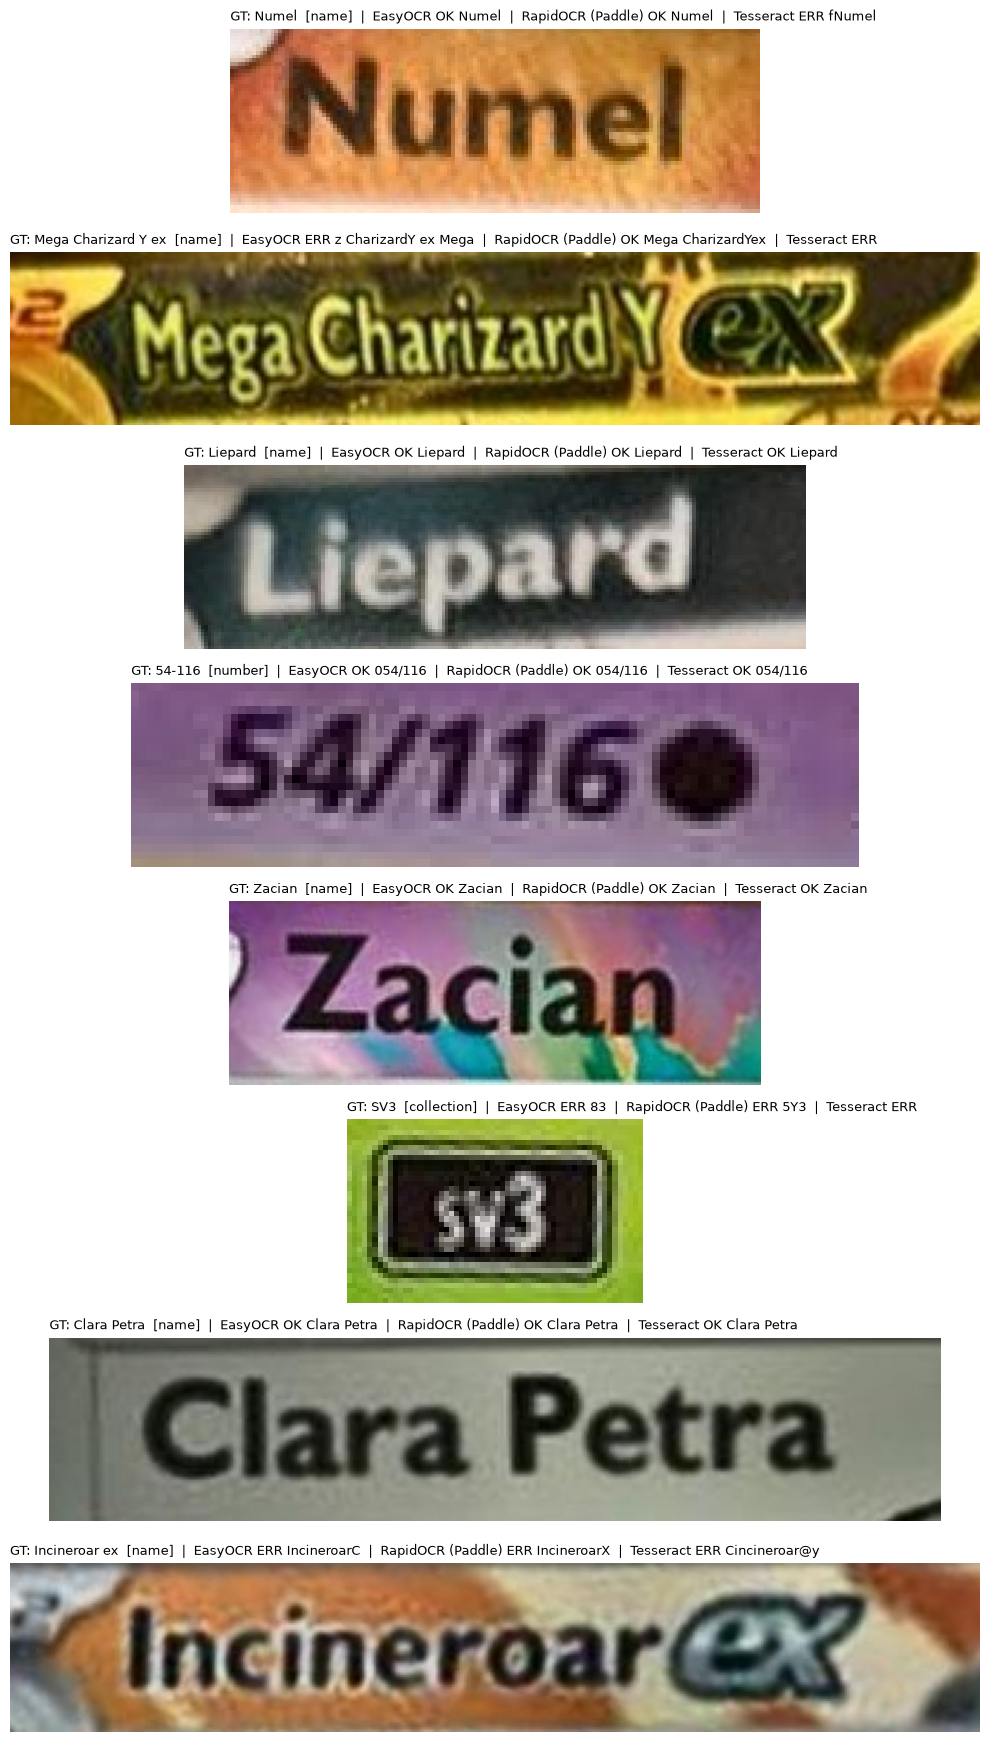

In [9]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
show = readable
if len(show) > MAX_SHOW:
    idx = rng.choice(show.index.to_numpy(), size=MAX_SHOW, replace=False)
    show = show.loc[sorted(idx)]

images = {p.name: p for p in (DATASET_DIR / EVAL_SPLIT / "images").iterdir()}
fig, axes = plt.subplots(len(show), 1, figsize=(10, 2.2 * max(len(show), 1)))
if len(show) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, show.iterrows()):
    img_path = images.get(row["imagem"])
    ax.axis("off")
    title = f"GT: {row['gt']}  [{row['tipo']}]"
    bits = [title]
    crop = None
    if img_path is not None:
        bgr = cv2.imread(str(img_path))
        lab = DATASET_DIR / EVAL_SPLIT / "labels" / f"{img_path.stem}.txt"
        if bgr is not None and lab.is_file():
            lines = [ln for ln in lab.read_text(encoding="utf-8").splitlines() if ln.strip()]
            if row["caixa"] < len(lines):
                parts = lines[int(row["caixa"])].split()
                h, w = bgr.shape[:2]
                pts = np.array(list(map(float, parts[1:9])), dtype=np.float32).reshape(4, 2)
                pts[:, 0] *= w
                pts[:, 1] *= h
                field = row["tipo"] if row["tipo"] in {"name", "number", "collection"} else "name"
                crop = warp_quad(bgr, pts, pad=_WARP_PAD.get(field, 0.12))
    if crop is not None and crop.size:
        rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
    for engine in ACTIVE:
        mark = "OK" if row[f"ok_clean_{engine}"] else "ERR"
        bits.append(f"{LABEL[engine]} {mark} {row[f'clean_{engine}']}")
    ax.set_title("  |  ".join(bits), fontsize=9, loc="left")
fig.tight_layout()
plt.show()